/opt/homebrew/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:1994: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return integrate.quad(self._pdf, _a, x, args=args)[0]
/opt/homebrew/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:1994: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  return integrate.quad(self._pdf, _a, x, args=arg

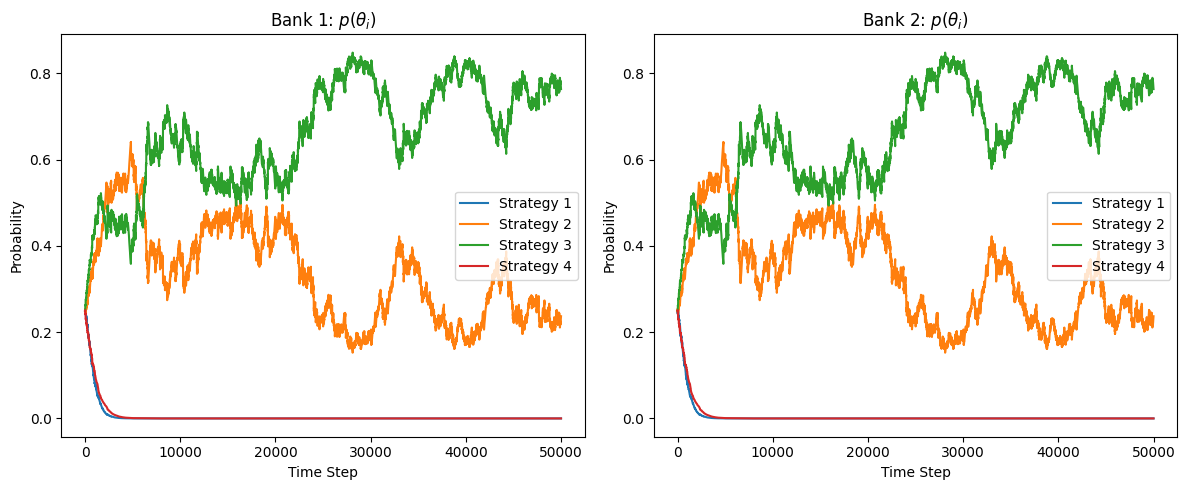

In [1]:
import numpy as np
from scipy.stats import truncnorm, rv_continuous
import matplotlib.pyplot as plt

# Distribution Definitions
def truncated_gaussian(mu=0.3, sigma=0.3, lower=0, upper=1):
    a, b = (lower - mu) / sigma, (upper - mu) / sigma
    return truncnorm(a, b, loc=mu, scale=sigma)

class piecewise_uniform(rv_continuous):
    def __init__(self, tau_l, tau_h, beta1=0.01, beta2=0.95):
        super().__init__(a=0, b=1)
        self.tau_l = tau_l
        self.tau_h = tau_h
        self.beta1 = beta1
        self.beta2 = beta2
        self.beta3 = 1 - (beta1 + beta2)
        self.norm1 = beta1 / tau_l
        self.norm2 = beta2 / (tau_h - tau_l)
        self.norm3 = self.beta3 / (1 - tau_h)

    def _pdf(self, y):
        if y < 0 or y > 1:
            return 0.0
        elif y <= self.tau_l:
            return self.norm1
        elif y <= self.tau_h:
            return self.norm2
        else:
            return self.norm3

# Utility function using 1 sample
def utility_from_sample(gamma, tau_a, tau_b, y):
    if tau_a <= y <= tau_b:
        return (2 + gamma) * y - 1
    else:
        return 0.0

# Utility matrix using sample
def get_sample_based_utility_matrix(gamma_l, gamma_h, tau_l, tau_h, dist):
    y = dist.rvs()  # get one sample

    U1 = np.array([
        [utility_from_sample(gamma_l, tau_l, 1, y)/2, 0, utility_from_sample(gamma_l, tau_h, 1, y)/2, 0],
        [utility_from_sample(gamma_l, tau_l, 1, y), utility_from_sample(gamma_h, tau_l, 1, y)/2,
         utility_from_sample(gamma_l, tau_h, 1, y), utility_from_sample(gamma_h, tau_h, 1, y)/2],
        [utility_from_sample(gamma_l, tau_l, tau_h, y) + utility_from_sample(gamma_l, tau_h, 1, y)/2,
         utility_from_sample(gamma_h, tau_l, tau_h, y), utility_from_sample(gamma_l, tau_h, 1, y)/2, 0],
        [utility_from_sample(gamma_l, tau_l, 1, y),
         utility_from_sample(gamma_h, tau_l, tau_h, y) + utility_from_sample(gamma_h, tau_h, 1, y)/2,
         utility_from_sample(gamma_l, tau_h, 1, y), utility_from_sample(gamma_h, tau_h, 1, y)/2]
    ])
    return U1

# Exponential Weights Algorithm using sampled U1 each step
def exponential_weights_sampled(T, eta, num_actions, gamma_l, gamma_h, tau_l, tau_h, dist):
    p1 = np.ones((T+1, num_actions)) / num_actions
    p2 = np.ones((T+1, num_actions)) / num_actions

    for t in range(T):
        U1 = get_sample_based_utility_matrix(gamma_l, gamma_h, tau_l, tau_h, dist)
        U2 = U1  # still assume zero-sum

        for k in range(num_actions):
            util1 = np.array([p2[t, j]*U1[j, k] for j in range(num_actions)])
            util2 = np.array([p1[t, j]*U2[j, k] for j in range(num_actions)])

            p1[t+1, k] = p1[t, k] * np.exp(eta * util1.sum())
            p2[t+1, k] = p2[t, k] * np.exp(eta * util2.sum())

        # Normalize
        p1[t+1] /= np.sum(p1[t+1])
        p2[t+1] /= np.sum(p2[t+1])

    return p1, p2

def plot_probabilities_per_player(p1, p2):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    for i in range(4):
        plt.plot(p1[:, i], label=f'Strategy {i+1}')
    plt.title(r'Bank 1: $p(\theta_i)$')
    plt.xlabel('Time Step')
    plt.ylabel('Probability')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    for i in range(4):
        plt.plot(p2[:, i], label=f'Strategy {i+1}')
    plt.title(r'Bank 2: $p(\theta_i)$')
    plt.xlabel('Time Step')
    plt.ylabel('Probability')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Run experiment
gamma_l, gamma_h = 0.6, 0.7
tau_l, tau_h = 1/(2+gamma_h), 1/(2+gamma_l)
dist = piecewise_uniform(tau_l, tau_h)

T = 50000
eta = 0.1
num_actions = 4

p1, p2 = exponential_weights_sampled(T, eta, num_actions, gamma_l, gamma_h, tau_l, tau_h, dist)
plot_probabilities_per_player(p1, p2)
